In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [3]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [4]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [5]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [6]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [7]:
indices_array = np.array(indices)
incomplete_file_ind = [5, 18, 26, 29]

In [8]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [9]:
exclude = [26, 33, 35, 36, 55, 56, 58, 59, 61, 66, 70, 73, 77, 80, 83, 90, 96]

In [10]:
df_list_refined = df_list.copy()
for ind in indices:
    if ind in exclude:
        df_list_refined[ind]='excluded'

indices_refined = list(set(indices)-set(top100.index[exclude]))

In [11]:
df_list_filtered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_filtered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_filtered.append('excluded')
        

In [12]:
columns = ('flare_list_id', 'start_time', 'end_time','peak_time', 'peak_counts', 'number_of_peaks', 'rise_time', 'decay_time','start_time (50-100 keV)', 'end_time (50-100 keV)', 'peak_counts (50-100 keV)', 'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'FWHM (25-50 keV)', 'FWHM (50-100 keV)', 'comments')
data=np.zeros((len(indices_refined), len(columns)))


In [13]:
filtered_stats_df = pd.DataFrame(data, columns = columns)

In [14]:
filtered_stats_df['flare_list_id'] = filtered_stats_df['flare_list_id'].astype(int)
label = 0
for loc, ind in enumerate(indices):
    if loc not in exclude:
        filtered_stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1

In [15]:
filtered_stats_df['start_time'] = filtered_stats_df['start_time'].astype(str)
filtered_stats_df['end_time'] = filtered_stats_df['end_time'].astype(str)
filtered_stats_df['rise_time'] = filtered_stats_df['rise_time'].astype(str)
filtered_stats_df['decay_time'] = filtered_stats_df['decay_time'].astype(str)
filtered_stats_df['peak_time'] = filtered_stats_df['peak_time'].astype(str)
filtered_stats_df['start_time (50-100 keV)'] = filtered_stats_df['start_time (50-100 keV)'].astype(str)
filtered_stats_df['end_time (50-100 keV)'] = filtered_stats_df['end_time (50-100 keV)'].astype(str)
filtered_stats_df['rise_time (50-100 keV)'] = filtered_stats_df['rise_time (50-100 keV)'].astype(str)
filtered_stats_df['decay_time (50-100 keV)'] = filtered_stats_df['decay_time (50-100 keV)'].astype(str)

In [16]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        r = top100['solo_position_AU_distance'].loc[ind]

        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        peak_counts_scaled = peak_counts/r**2
        filtered_stats_df.loc[label, 'peak_counts'] = peak_counts_scaled
        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        filtered_stats_df.loc[label, 'peak_time'] = str(peak_loc)

        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        tstart = flare.index[0]
        tend = plot_df[(plot_df['25.0 keV-50.0 keV']<10/r**2) & (plot_df.index>peak_loc)].index[0]

        filtered_stats_df.loc[label, 'start_time'] = str(tstart)
        filtered_stats_df.loc[label, 'end_time'] = str(tend)
        
        plot_df = plot_df.truncate(t(tstart), t(tend))

        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        filtered_stats_df.loc[label, 'rise_time'] = str(rise_time).split(" ")[-1]
        filtered_stats_df.loc[label, 'decay_time'] = str(decay_time).split(" ")[-1]

        peak_counts_50_100 = np.max(plot_df['50.0 keV-100.0 keV'])
        peak_counts_50_100_scaled = peak_counts_50_100/r**2
        filtered_stats_df.loc[label, 'peak_counts (50-100 keV)'] = peak_counts_50_100_scaled
        peak_loc_50_100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] == peak_counts_50_100][0]

        flare_50_100 = plot_df[plot_df['50.0 keV-100.0 keV']>3/r**2]

        if flare_50_100.empty:
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = np.nan
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = np.nan
        
        else:
            tstart_50_100 = flare_50_100.index[0]
            #tend_50_100 = flare_50_100.index[-1]
            # tend_50_100 = plot_df[(plot_df['50.0 keV-100.0 keV']<3/r**2) & (plot_df.index>peak_loc_50_100)]
            # if tend_50_100.empty:
            #     findend = plot_df[(plot_df.index>peak_loc_50_100)&(plot_df.index<t(tend))]
            #     tend_50_100 = findend.index[findend['50.0 keV-100.0 keV'] == np.min(findend['50.0 keV-100.0 keV'])][-1]
            # else:
                #tend_50_100 = tend_50_100.index[0]
            tend_50_100 = flare_50_100.index[-1]

            rise_time_50_100 = peak_loc_50_100 - tstart_50_100
            decay_time_50_100 = tend_50_100 - peak_loc_50_100
            filtered_stats_df.loc[label, 'rise_time (50-100 keV)'] = str(rise_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'decay_time (50-100 keV)'] = str(decay_time_50_100).split(" ")[-1]
            filtered_stats_df.loc[label, 'start_time (50-100 keV)'] = str(tstart_50_100)
            filtered_stats_df.loc[label, 'end_time (50-100 keV)'] = str(tend_50_100)

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        filtered_stats_df.loc[label, 'number_of_peaks'] = len(peaks)
        #peak_locs[label]=peaks

        label+=1
    i+=1

In [17]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted', label='10 counts/keV s (scaled)')
        plt.axhline(3/r**2, 0, 1, color='salmon', linestyle='dotted', label='3 counts/keV s (scaled)')

        if pd.notna(tend_50_100):
            plt.axvline(t(tend_50_100), 0, 1, color = 'pink', linestyle = 'dashed', label = 'Estimated Start/End (50-100 keV)')
            plt.axvline(t(tstart_50_100), 0, 1, color = 'pink', linestyle = 'dashed')

        rise_time_td = pd.to_timedelta(filtered_stats_df['rise_time'].iloc[i])
        decay_time_td = pd.to_timedelta(filtered_stats_df['decay_time'].iloc[i])
        
        duration = rise_time_td+decay_time_td
        duration = duration.total_seconds()
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(seconds=0.1*duration), t(tend)+dt.timedelta(seconds=0.1*duration))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered_cropped/top_100_flares_science_data_plot"+str(i)+"_filtered_cropped.png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_21836\2307101718.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [18]:
rise_time_td = pd.to_timedelta(filtered_stats_df['rise_time'])
decay_time_td = pd.to_timedelta(filtered_stats_df['decay_time'])

durations = rise_time_td+decay_time_td
durations = durations.dt.total_seconds()

In [22]:
np.where(np.array(durations)>2000)

(array([7]),)

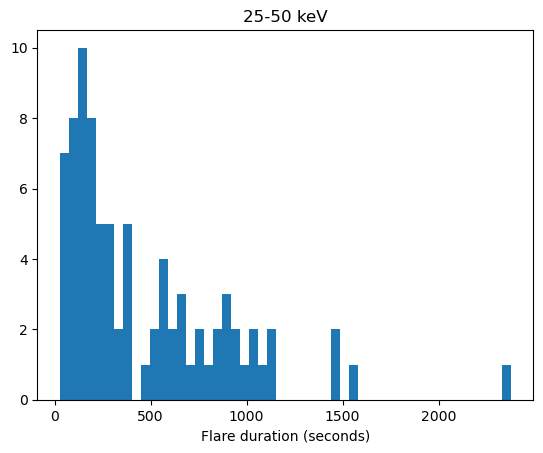

In [23]:
plt.hist(durations, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_filtered.png", bbox_inches='tight')

In [24]:
rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])

durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
durations_50_100 = durations_50_100.dt.total_seconds()

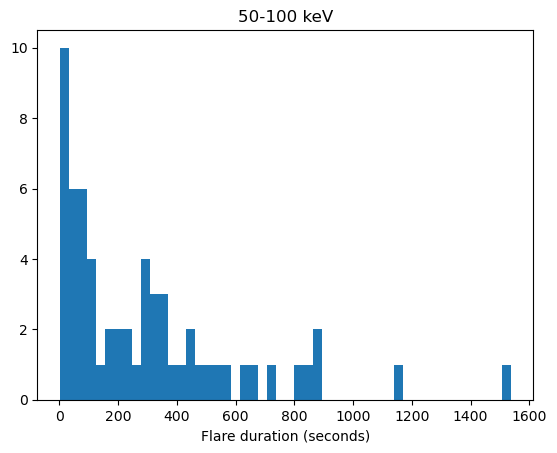

In [25]:
plt.hist(durations_50_100, bins=50)
plt.xlabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_hist_50_100_filtered.png", bbox_inches='tight')

In [26]:
from scipy.stats import spearmanr, pearsonr

In [27]:
spearmanr(filtered_stats_df['peak_counts'], durations)

SignificanceResult(statistic=np.float64(0.5241753513507197), pvalue=np.float64(3.660326634425816e-07))

In [28]:
pearsonr(filtered_stats_df['peak_counts'], durations)

PearsonRResult(statistic=np.float64(0.10931588030311658), pvalue=np.float64(0.32523182271072987))

In [29]:
pearsonr(np.log10(filtered_stats_df['peak_counts']), np.log10(durations))

PearsonRResult(statistic=np.float64(0.48700449280602365), pvalue=np.float64(3.031061942010146e-06))

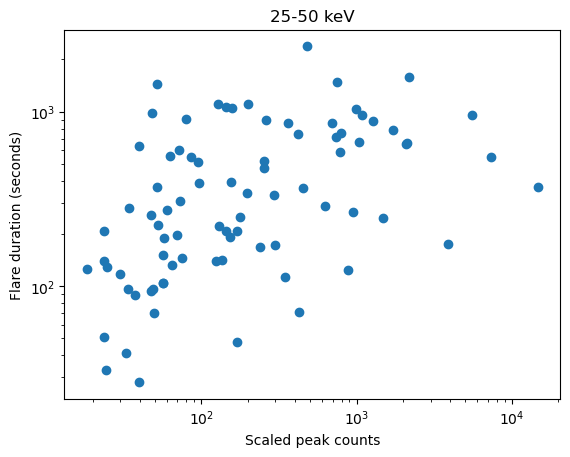

In [30]:
plt.scatter(filtered_stats_df['peak_counts'], durations)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.xlabel('Scaled peak counts')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_filtered.png", bbox_inches='tight')

In [31]:
duration_50_100_corr = []
peak_counts_50_100_corr = []
for i in range(len(durations_50_100)):
    if pd.notna(durations_50_100[i]):
        duration_50_100_corr.append(durations_50_100[i])
        peak_counts_50_100_corr.append(filtered_stats_df['peak_counts (50-100 keV)'].iloc[i])

In [32]:
spearmanr(peak_counts_50_100_corr, duration_50_100_corr)

SignificanceResult(statistic=np.float64(0.4590528083831233), pvalue=np.float64(0.00019835139699588767))

In [33]:
pearsonr(peak_counts_50_100_corr, duration_50_100_corr)

PearsonRResult(statistic=np.float64(0.0932072744449953), pvalue=np.float64(0.4749369064392526))

In [34]:
pearsonr(np.log10(peak_counts_50_100_corr), np.log10(duration_50_100_corr))

PearsonRResult(statistic=np.float64(0.45429940579541744), pvalue=np.float64(0.00023532987582555327))

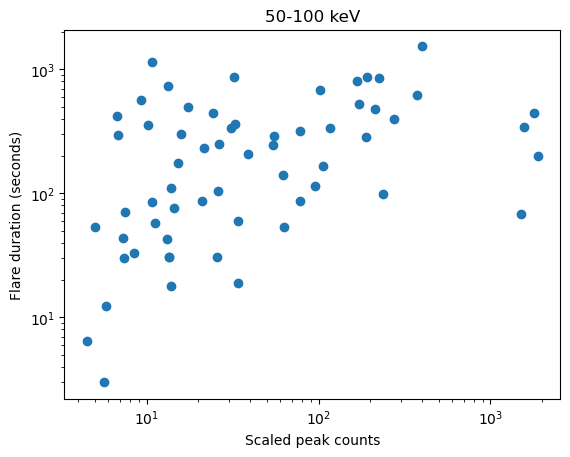

In [35]:
plt.scatter(filtered_stats_df['peak_counts (50-100 keV)'], durations_50_100)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.xlabel('Scaled peak counts')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_counts_50_100_filtered.png", bbox_inches='tight')

Text(0.5, 0, 'Ratio of peaks (50-100 keV:25-50 keV)')

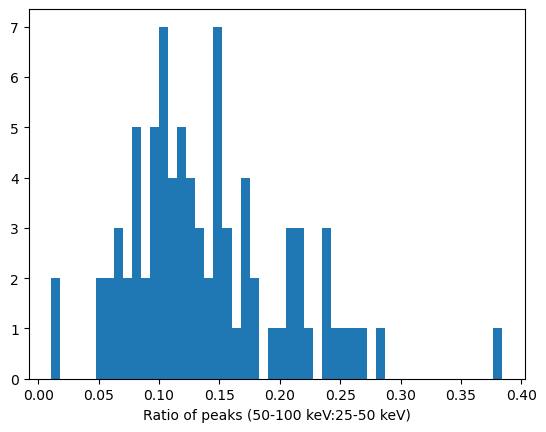

In [36]:
peak_ratios = filtered_stats_df['peak_counts (50-100 keV)']/filtered_stats_df['peak_counts']
plt.hist(peak_ratios, bins=50)
plt.xlabel('Ratio of peaks (50-100 keV:25-50 keV)')

In [37]:
rise_time_td

0           0 days 00:03:23
1           0 days 00:01:10
2           0 days 00:04:37
3           0 days 00:03:29
4    0 days 00:08:12.500000
              ...          
78          0 days 00:01:42
79          0 days 00:01:07
80          0 days 00:00:15
81          0 days 00:00:53
82          0 days 00:01:45
Name: rise_time, Length: 83, dtype: timedelta64[us]

(array([17., 25.,  9.,  6.,  6.,  1.,  3.,  2.,  1.,  0.,  3.,  4.,  0.,
         1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.05708013,  0.27800749,  0.49893486,  0.71986222,  0.94078958,
         1.16171695,  1.38264431,  1.60357167,  1.82449903,  2.0454264 ,
         2.26635376,  2.48728112,  2.70820849,  2.92913585,  3.15006321,
         3.37099057,  3.59191794,  3.8128453 ,  4.03377266,  4.25470003,
         4.47562739,  4.69655475,  4.91748212,  5.13840948,  5.35933684,
         5.5802642 ,  5.80119157,  6.02211893,  6.24304629,  6.46397366,
         6.68490102,  6.90582838,  7.12675574,  7.34768311,  7.56861047,
         7.78953783,  8.0104652 ,  8.23139256,  8.45231992,  8.67324728,
         8.89417465,  9.11510201,  9.33602937,  9.55695674,  9.7778841 ,
         9.99881146, 10.21973882, 10.44066619, 10.66159355,

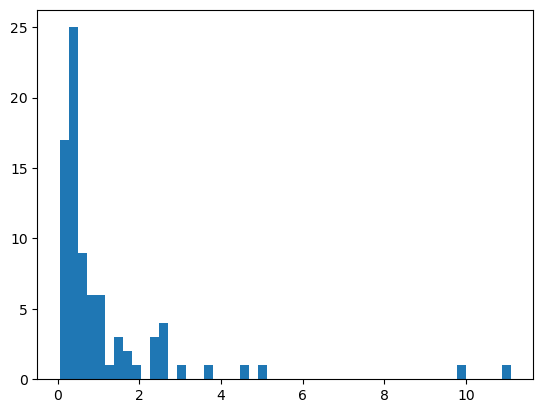

In [38]:
rise_time_s = rise_time_td.dt.total_seconds()
decay_time_s = decay_time_td.dt.total_seconds()

rise_decay_ratio = rise_time_s/decay_time_s

rise_time_s_50100 = rise_time_50_100_td.dt.total_seconds()
decay_time_s_50100 = decay_time_50_100_td.dt.total_seconds()

rise_decay_ratio_50100 = rise_time_s_50100/decay_time_s_50100

plt.hist(rise_decay_ratio, bins=50)

(array([16., 12.,  5.,  5.,  9.,  0.,  4.,  1.,  1.,  2.,  0.,  1.,  1.,
         0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.03541076,  0.25605672,  0.47670267,  0.69734862,  0.91799457,
         1.13864052,  1.35928647,  1.57993242,  1.80057838,  2.02122433,
         2.24187028,  2.46251623,  2.68316218,  2.90380813,  3.12445408,
         3.34510004,  3.56574599,  3.78639194,  4.00703789,  4.22768384,
         4.44832979,  4.66897574,  4.88962169,  5.11026765,  5.3309136 ,
         5.55155955,  5.7722055 ,  5.99285145,  6.2134974 ,  6.43414335,
         6.65478931,  6.87543526,  7.09608121,  7.31672716,  7.53737311,
         7.75801906,  7.97866501,  8.19931097,  8.41995692,  8.64060287,
         8.86124882,  9.08189477,  9.30254072,  9.52318667,  9.74383263,
         9.96447858, 10.18512453, 10.40577048, 10.62641643,

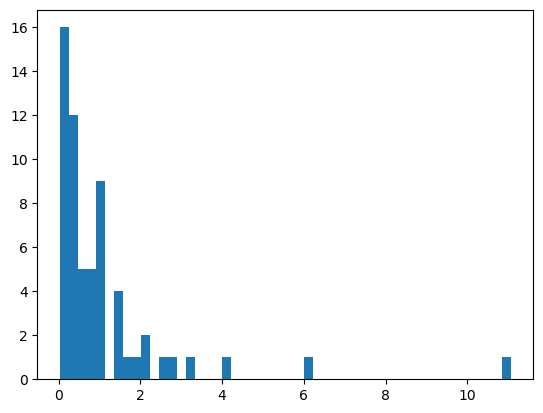

In [39]:
plt.hist(rise_decay_ratio_50100, bins=50)

In [40]:
spearmanr(peak_ratios, durations)

SignificanceResult(statistic=np.float64(0.1844820167392722), pvalue=np.float64(0.0950013695314923))

In [41]:
pearsonr(peak_ratios, durations)

PearsonRResult(statistic=np.float64(0.13847039280089407), pvalue=np.float64(0.21187820119598716))

In [42]:
pearsonr(peak_ratios, np.log10(durations))

PearsonRResult(statistic=np.float64(0.1404184119961214), pvalue=np.float64(0.20545745911150223))

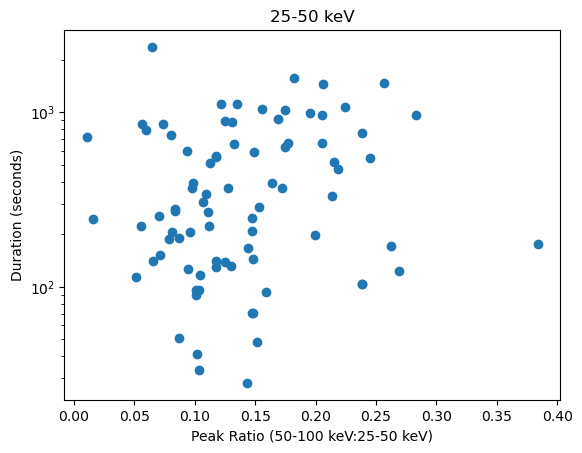

In [43]:
plt.scatter(peak_ratios, durations)
plt.yscale('log')
plt.xlabel('Peak Ratio (50-100 keV:25-50 keV)')
plt.ylabel('Duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_ratio.png", bbox_inches='tight')

In [44]:
peak_ratios_50100_corr=[]
for i in range(len(peak_ratios)):
    if pd.notna(durations_50_100[i]):
        peak_ratios_50100_corr.append(peak_ratios[i])

In [45]:
spearmanr(peak_ratios_50100_corr, duration_50_100_corr)

SignificanceResult(statistic=np.float64(0.25816431844725996), pvalue=np.float64(0.04455749826215073))

In [46]:
pearsonr(peak_ratios_50100_corr, duration_50_100_corr)

PearsonRResult(statistic=np.float64(0.17678847314349283), pvalue=np.float64(0.17289509455184376))

In [47]:
pearsonr(peak_ratios_50100_corr, np.log10(duration_50_100_corr))

PearsonRResult(statistic=np.float64(0.19368549574632063), pvalue=np.float64(0.13474751281817698))

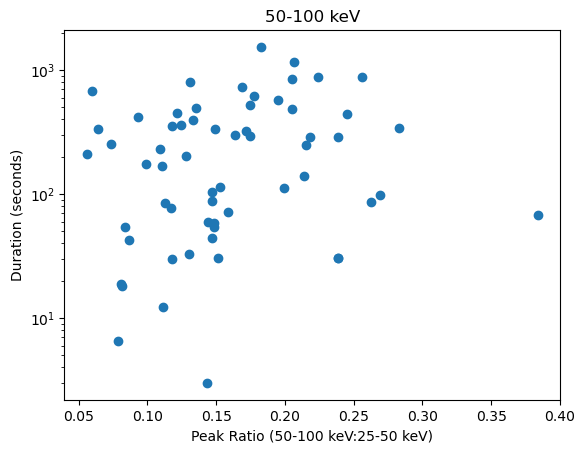

In [48]:
plt.scatter(peak_ratios, durations_50_100)
plt.yscale('log')
plt.xlabel('Peak Ratio (50-100 keV:25-50 keV)')
plt.ylabel('Duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_filtered/duration_vs_peak_ratio_50_100.png", bbox_inches='tight')

In [49]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        sci_df = df_list[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted', label='10 counts/keV s (scaled)')
        plt.axhline(3/r**2, 0, 1, color='salmon', linestyle='dotted', label='3 counts/keV s (scaled)')

        if pd.notna(tend_50_100):
            plt.axvline(t(tend_50_100), 0, 1, color = 'pink', linestyle = 'dashed', label = 'Estimated Start/End (50-100 keV)')
            plt.axvline(t(tstart_50_100), 0, 1, color = 'pink', linestyle = 'dashed')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='center right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/top_100_flares_refined/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\2550614291.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [19]:
label=0
i=0
half_max_points = []
half_max_vals = []
end_points = []
end_point_vals = []
fwhm_list = []
half_max_points_50100 = []
half_max_vals_50100 = []
end_points_50100 = []
end_point_vals_50100 = []
fwhm_list_50100 = []
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
    
        tstart = filtered_stats_df['start_time'].iloc[label]
        tend = filtered_stats_df['end_time'].iloc[label]
        tpeak = filtered_stats_df['peak_time'].iloc[label]

        r = top100['solo_position_AU_distance'].loc[ind]
        max_counts = (filtered_stats_df['peak_counts'].iloc[label])*r**2

        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        half_max = 0.5*max_counts
        half_max_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] >= half_max][0]
        half_max_points.append(half_max_loc)
        half_max_vals.append(half_max)

        over_half = np.where(plot_df['25.0 keV-50.0 keV']>half_max)
        end_point = plot_df.index[over_half[0][-1]]
        end_points.append(end_point)
        end_point_vals.append(plot_df['25.0 keV-50.0 keV'].iloc[over_half[0][-1]])

        # rise_time_50_100_td = pd.to_timedelta(filtered_stats_df['rise_time (50-100 keV)'])
        # decay_time_50_100_td = pd.to_timedelta(filtered_stats_df['decay_time (50-100 keV)'])
        
        # durations_50_100 = rise_time_50_100_td+decay_time_50_100_td
        # durations_50_100 = durations_50_100.dt.total_seconds()

        fwhm = (t(end_point)-t(half_max_loc))
            #.total_seconds()
        fwhm_list.append(fwhm)

        filtered_stats_df.loc[label, 'FWHM (25-50 keV)'] = fwhm.total_seconds()

        if pd.notna(filtered_stats_df['start_time (50-100 keV)'].iloc[label]):
            max_counts_50100 = (filtered_stats_df['peak_counts (50-100 keV)'].iloc[label])*r**2
    
            half_max_50100 = 0.5*max_counts_50100
            half_max_loc_50100 = plot_df.index[plot_df['50.0 keV-100.0 keV'] >= half_max_50100][0]
            half_max_points_50100.append(half_max_loc_50100)
            half_max_vals_50100.append(half_max_50100)
    
            over_half_50100 = np.where(plot_df['50.0 keV-100.0 keV']>half_max_50100)
            end_point_50100 = plot_df.index[over_half_50100[0][-1]]
            end_points_50100.append(end_point_50100)
            end_point_vals_50100.append(plot_df['50.0 keV-100.0 keV'].iloc[over_half_50100[0][-1]])
            
            fwhm_50100 = (t(end_point_50100)-t(half_max_loc_50100))
                #.total_seconds()
            fwhm_list_50100.append(fwhm_50100)

            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = fwhm_50100.total_seconds()

        else:
            filtered_stats_df.loc[label, 'FWHM (50-100 keV)'] = np.nan
            fwhm_list_50100.append(np.nan)
            half_max_vals_50100.append(np.nan)
            half_max_points_50100.append(np.nan)
            end_points_50100.append(np.nan)
            end_point_vals_50100.append(np.nan)
            
        label+=1
    i+=1

In [51]:
#half_max_points_50100

In [52]:
t(half_max_loc) + fwhm

datetime.datetime(2022, 5, 1, 8, 13, 31, 531000)

In [53]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Threshold Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

        ax.plot(t(half_max_points[i]), half_max_vals[i], marker='o',ms=3, color='lightseagreen')
        ax.hlines(half_max_vals[i], t(half_max_points[i]), t(half_max_points[i]) + fwhm_list[i], linestyle='dashed', color='lightseagreen')
        ax.plot(t(end_points[i]), end_point_vals[i], marker='o', ms=3, color='lightseagreen')
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

        if pd.notna(fwhm_list_50100[i]):
            ax.plot(t(half_max_points_50100[i]), half_max_vals_50100[i], marker='o', ms=3, color='lightseagreen')
            ax.hlines(half_max_vals_50100[i], t(half_max_points_50100[i]), t(half_max_points_50100[i]) + fwhm_list_50100[i], linestyle='dashed', color='lightseagreen')
            ax.plot(t(end_points_50100[i]), end_point_vals_50100[i], marker='o', ms=3, color='lightseagreen')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='center right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\4023440309.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


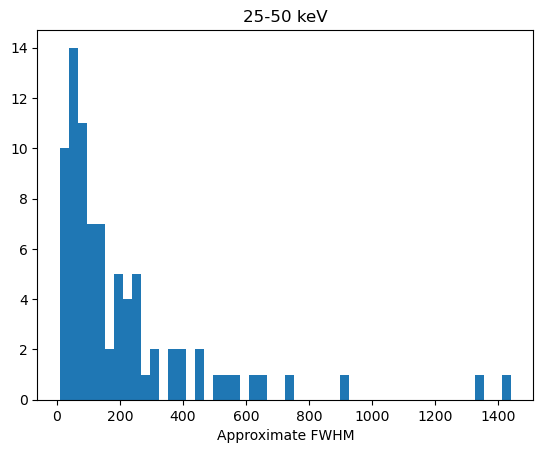

In [54]:
plt.hist(filtered_stats_df['FWHM (25-50 keV)'], bins=50)
plt.xlabel('Approximate FWHM')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/fwhm_hist.png", bbox_inches='tight')

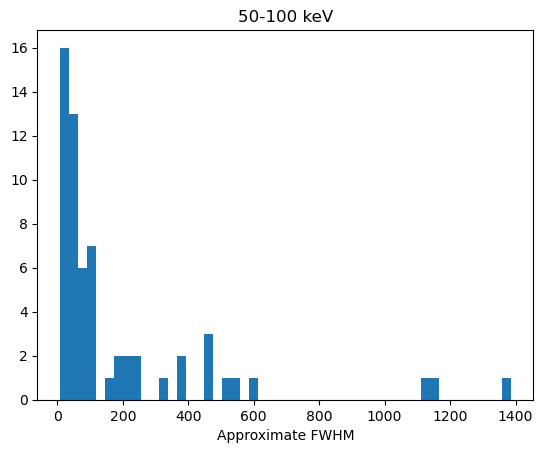

In [55]:
plt.hist(filtered_stats_df['FWHM (50-100 keV)'], bins=50)
plt.xlabel('Approximate FWHM')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/fwhm_50_100_hist.png", bbox_inches='tight')

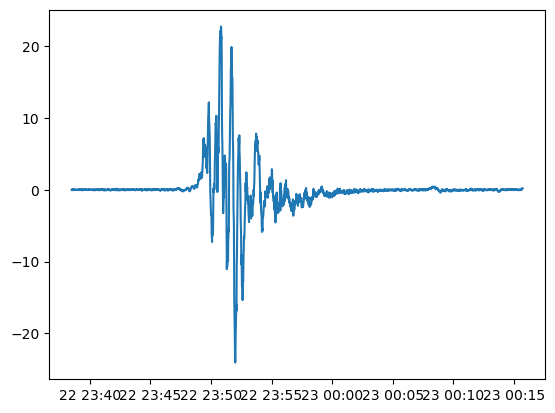

In [56]:
tstart = filtered_stats_df['start_time'].iloc[0]
tend = filtered_stats_df['end_time'].iloc[0]

plot_df= df_list_filtered[0].truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
plt.plot(plot_df.index, plot_df['25.0 keV-50.0 keV'].diff())

In [57]:
test_df = plot_df[plot_df['25.0 keV-50.0 keV'].diff()>0.1]


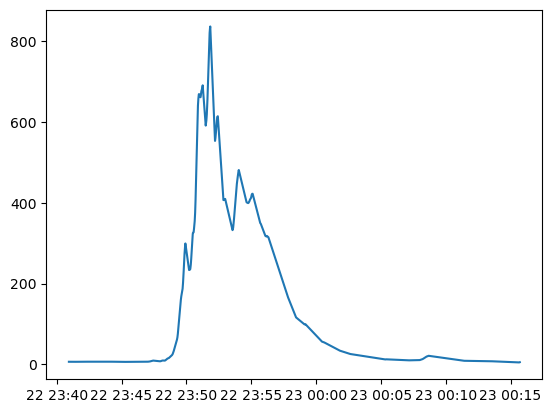

In [58]:
plt.plot(test_df.index, test_df['25.0 keV-50.0 keV'])

In [23]:
df_list_extrafiltered = []
for loc, ind in enumerate(indices):
    if ind in indices_refined:
        df_filtered  = df_list[loc].copy()
        
        filtered_2550 = savgol_filter(df_list[loc]['25.0 keV-50.0 keV'], window_length = 305, polyorder=2)
        filtered_50100 = savgol_filter(df_list[loc]['50.0 keV-100.0 keV'], window_length = 305, polyorder=2)

        df_filtered['25.0 keV-50.0 keV'] = filtered_2550
        df_filtered['50.0 keV-100.0 keV'] = filtered_50100

        df_list_extrafiltered.append(df_filtered)
        
    if ind not in indices_refined:
        df_list_extrafiltered.append('excluded')

<Axes: >

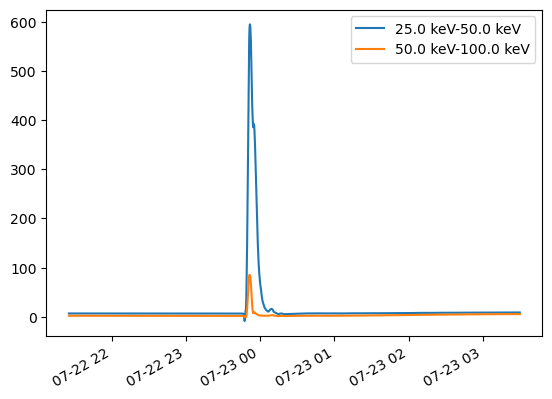

In [60]:
df_list_extrafiltered[0].plot()

In [61]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_extrafiltered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        #plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        test_df = plot_df[np.abs(plot_df['25.0 keV-50.0 keV'].diff())>0.1]

        sci_df = df_list[np.where(indices_array==ind)[0][0]]
        plot_df = sci_df.truncate(start, end)
        
        ax.plot(plot_df.index, plot_df['25.0 keV-50.0 keV'])
        ax.plot(test_df.index, test_df['25.0 keV-50.0 keV'], 'o', ms=1)

        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

# tstart = filtered_stats_df['start_time'].iloc[0]
# tend = filtered_stats_df['end_time'].iloc[0]

# plot_df= df_list_filtered[0].truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
# plt.plot(plot_df.index, plot_df['25.0 keV-50.0 keV'].diff())

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\2024038843.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [62]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        # plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Estimated Start/End (25-50 keV)')
        # plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
        # plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted', label='10 counts/keV s (scaled)')
        # plt.axhline(3/r**2, 0, 1, color='salmon', linestyle='dotted', label='3 counts/keV s (scaled)')

        # if pd.notna(tend_50_100):
        #     plt.axvline(t(tend_50_100), 0, 1, color = 'pink', linestyle = 'dashed', label = 'Estimated Start/End (50-100 keV)')
        #     plt.axvline(t(tstart_50_100), 0, 1, color = 'pink', linestyle = 'dashed')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=15, prominence=0.1*peak_counts)

        # sci_df = df_list[np.where(indices_array==ind)[0][0]]
        # plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

        plt.scatter(plot_df.index[peaks], plot_df['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/peak_testing/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\1008863599.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [63]:
i=0
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
        plot_df = sci_df.truncate(start, end)
             
        plot_df.index = t(plot_df.index)
        
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    
        # plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
        # plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
        # plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
        # plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

        # r = top100['solo_position_AU_distance'].loc[ind]
        
        # flare = plot_df[plot_df['25.0 keV-50.0 keV']>10/r**2]
        # tstart = flare.index[0]
        # tend = flare.index[-1]
    
        # if t(tend) in plot_df.index:
        #     plt.axvline(t(tend), 0, 1, color = 'pink', linestyle = 'dotted', label = 'Estimated Start/End')
        # if t(tstart) in plot_df.index:
        #     plt.axvline(t(tstart), 0, 1, color = 'pink', linestyle = 'dotted')
        
        #plt.axhline(10/r**2, 0, 1, color='red', linestyle='dotted')
        plt.yscale('log')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/log_scale_flares/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\4076301437.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [64]:
df_list_extrafiltered[0].shape

(12851, 2)

In [21]:
bad_diff = [1, 7, 9, 23, 25, 26, 27, 33, 40, 47, 61, 73, 75, 35, 37, 41, 42, 44, 52, 53, 56, 58, 60, 63, 67, 70, 74, 76, 78, 80]

In [136]:

i=0
for ind in indices:
    if ind in indices_refined:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
        sci_df = df_list_extrafiltered[np.where(indices_array==ind)[0][0]]

        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        #plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))

        test_df = plot_df[np.abs(plot_df['25.0 keV-50.0 keV'].diff())>0.05]
        diff_estimated_start = test_df.index[0]
        diff_estimated_end = test_df.index[-1]

        estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()

        # if pd.notna(fwhm_list_50100[i]):
        #     test_df_50100 = test_df[np.abs(test_df['50.0 keV-100.0 keV'].diff())>0.02]
        #     diff_estimated_start_50100 = test_df_50100.index[0]
        #     diff_estimated_end_50100 = test_df_50100.index[-1]

        #     estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()

        #     plt.axvline(diff_estimated_start_50100, 0, 1, color = 'red', linestyle = 'dashed')
        #     plt.axvline(diff_estimated_end_50100, 0, 1, color = 'red', linestyle = 'dashed')

        plt.axvline(diff_estimated_start, 0, 1, color = 'palevioletred', linestyle = 'dashed')
        plt.axvline(diff_estimated_end, 0, 1, color = 'palevioletred', linestyle = 'dashed')
        
        sci_df = df_list[np.where(indices_array==ind)[0][0]]
        
        tstart = t(filtered_stats_df['start_time'].iloc[i]) - dt.timedelta(minutes=10)
        tend = t(filtered_stats_df['end_time'].iloc[i]) + dt.timedelta(minutes=10)

        plot_df = sci_df.truncate(start, end)
        
        ax.plot(plot_df.index, plot_df['25.0 keV-50.0 keV'])
        ax.plot(plot_df.index, plot_df['50.0 keV-100.0 keV'])
        #ax.plot(test_df.index, test_df['25.0 keV-50.0 keV'], 'o', ms=1)

        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/flare"+str(i)+".png", bbox_inches='tight')
        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\1195446213.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [24]:
durations_diff = []
estimated_starts = []
estimated_ends = []
durations_diff_50100 = []
estimated_starts_50100 = []
estimated_ends_50100 = []
i=0
for ind in indices:
    if ind in indices_refined:
        if i not in bad_diff:
            fig, ax = plt.subplots()
            ax.set_ylabel('ct/(keV s)')
            ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
            sci_df = df_list_extrafiltered[np.where(indices_array==ind)[0][0]]

            start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
            end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
            plot_df = sci_df.truncate(start, end)
            plot_df.index = parse_time(plot_df.index).datetime 
            #plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=10), t(tend)+dt.timedelta(minutes=10))
    
            test_df = plot_df[np.abs(plot_df['25.0 keV-50.0 keV'].diff())>0.05]
            diff_estimated_start = test_df.index[0]
            diff_estimated_end = test_df.index[-1]

            estimated_starts.append(diff_estimated_start)
            estimated_ends.append(diff_estimated_end)

            estimated_duration = (diff_estimated_end - diff_estimated_start).total_seconds()
            durations_diff.append(estimated_duration)

            if pd.notna(fwhm_list_50100[i]):
                test_df_50100 = test_df[np.abs(test_df['50.0 keV-100.0 keV'].diff())>0.02]
                diff_estimated_start_50100 = test_df_50100.index[0]
                diff_estimated_end_50100 = test_df_50100.index[-1]
    
                estimated_starts_50100.append(diff_estimated_start_50100)
                estimated_ends_50100.append(diff_estimated_end_50100)
    
                estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
                durations_diff_50100.append(estimated_duration_50100)
    
                plt.axvline(diff_estimated_start_50100, 0, 1, color = 'red', linestyle = 'dashed')
                plt.axvline(diff_estimated_end_50100, 0, 1, color = 'red', linestyle = 'dashed')
            else:
                durations_diff_50100.append(np.nan)
                estimated_starts_50100.append(np.nan)
                estimated_ends_50100.append(np.nan)

            plt.axvline(diff_estimated_start, 0, 1, color = 'pink', linestyle = 'dotted')
            plt.axvline(diff_estimated_end, 0, 1, color = 'pink', linestyle = 'dotted')
            
            sci_df = df_list[np.where(indices_array==ind)[0][0]]
            
            tstart = t(filtered_stats_df['start_time'].iloc[i]) - dt.timedelta(minutes=10)
            tend = t(filtered_stats_df['end_time'].iloc[i]) + dt.timedelta(minutes=10)
    
            plot_df = sci_df.truncate(start, end)
            
        #     ax.plot(plot_df.index, plot_df['25.0 keV-50.0 keV'])
        #     ax.plot(plot_df.index, plot_df['50.0 keV-100.0 keV'])
        #     #ax.plot(test_df.index, test_df['25.0 keV-50.0 keV'], 'o', ms=1)
    
        #     fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/difference_good_flares/flare"+str(i)+".png", bbox_inches='tight')
        else:
            durations_diff.append(np.nan)
            estimated_starts.append(np.nan)
            estimated_ends.append(np.nan)
            durations_diff_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)
        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_21836\887616127.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


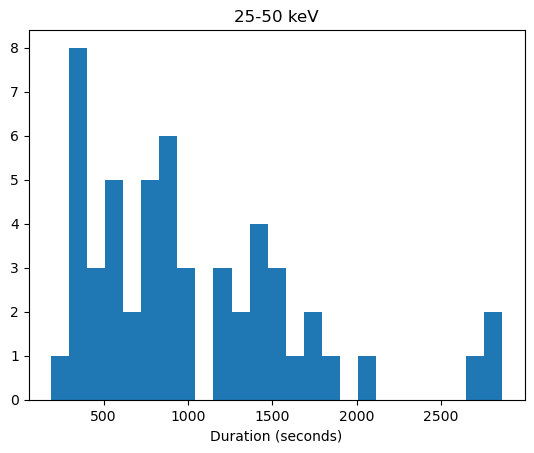

In [67]:
plt.hist(durations_diff, bins=25)
plt.xlabel('Duration (seconds)')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/difference_good_flares/duration_hist_diff_method.png", bbox_inches='tight')

In [155]:
avg_dur = []
for dur in durations_diff:
    if pd.notna(dur):
        avg_dur.append(dur)

avg_dur_50100 = []
for dur in durations_diff_50100:
    if pd.notna(dur):
        avg_dur_50100.append(dur)

(array([1., 8., 3., 5., 2., 5., 6., 3., 0., 3., 2., 4., 3., 1., 2., 1., 0.,
        1., 0., 0., 0., 0., 0., 1., 2.]),
 array([ 188.5  ,  295.482,  402.464,  509.446,  616.428,  723.41 ,
         830.392,  937.374, 1044.356, 1151.338, 1258.32 , 1365.302,
        1472.284, 1579.266, 1686.248, 1793.23 , 1900.212, 2007.194,
        2114.176, 2221.158, 2328.14 , 2435.122, 2542.104, 2649.086,
        2756.068, 2863.05 ]),
 <BarContainer object of 25 artists>)

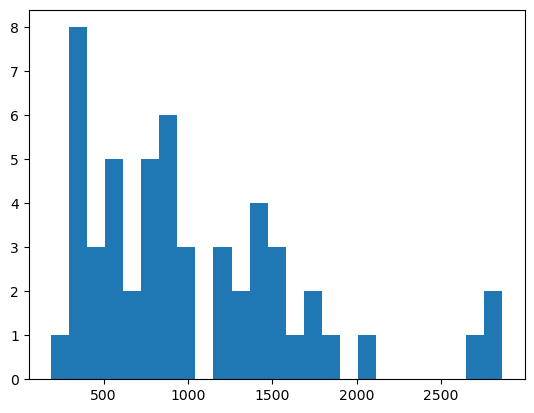

In [154]:
plt.hist(avg_dur, bins=25)

In [148]:
np.mean(avg_dur)

np.float64(1028.9356415094342)

In [156]:
np.mean(avg_dur_50100)

np.float64(941.5616428571427)

In [149]:
np.median(avg_dur)

np.float64(902.0)

In [68]:
durations_test = []
for i in range(len(durations)):
    if i not in bad_diff:
        durations_test.append(durations[i])

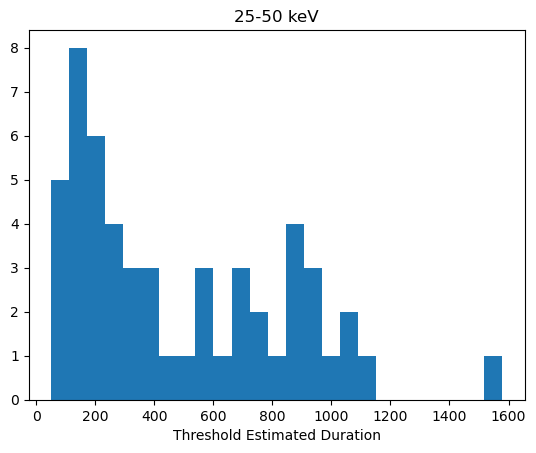

In [69]:
plt.hist(durations_test, bins=25)
plt.xlabel('Threshold Estimated Duration')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/difference_good_flares/duration_hist_threshold_method.png", bbox_inches='tight')

In [70]:
durations_test_50100 = []
for i in range(len(durations_50_100)):
    if i not in bad_diff:
        durations_test_50100.append(durations_50_100[i])

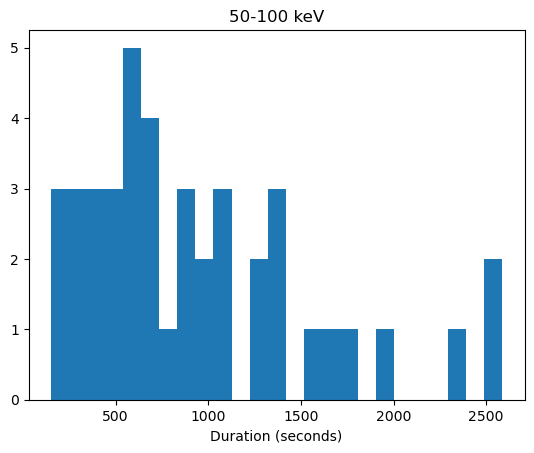

In [71]:
plt.hist(durations_diff_50100, bins=25)
plt.xlabel('Duration (seconds)')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/difference_good_flares/duration_hist_50100_diff_method.png", bbox_inches='tight')

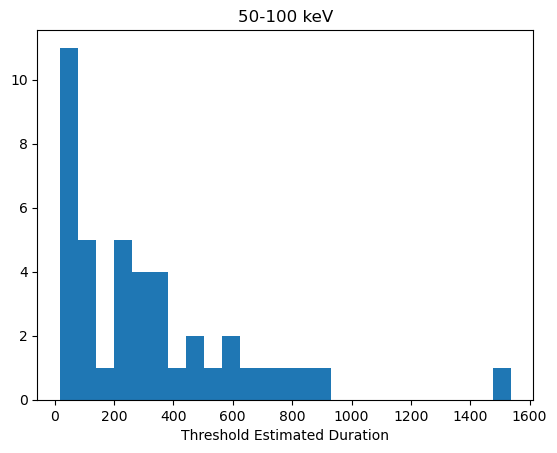

In [72]:
plt.hist(durations_test_50100, bins=25)
plt.xlabel('Threshold Estimated Duration')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/difference_testing/difference_good_flares/duration_hist_50100_threshold_method.png", bbox_inches='tight')

In [73]:
np.where(np.array(durations_diff)>3000)

(array([], dtype=int64),)

In [74]:
def gauss(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

In [160]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        # if i not in bad_diff:
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        sci_df = df_list[np.where(indices_array==ind)[0][0]]

        r = top100['solo_position_AU_distance'].loc[ind]
        
        tstart = filtered_stats_df['start_time'].iloc[i]
        tend = filtered_stats_df['end_time'].iloc[i]

        tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
        tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

        plt.axvline(t(tend), 0, 1, color = 'limegreen', linestyle = 'dashed', label = 'Threshold Estimated Start/End (25-50 keV)')
        plt.axvline(t(tstart), 0, 1, color = 'limegreen', linestyle = 'dashed')
        plt.axvline(estimated_starts[i], 0, 1, linestyle = 'dotted', color='red', label = 'Difference Estimated Start/End (25-50 keV)')
        plt.axvline(estimated_ends[i], 0, 1, linestyle = 'dotted', color='red')
        
        plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=20), t(tend)+dt.timedelta(minutes=20))
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

        ax.plot(t(half_max_points[i]), half_max_vals[i], marker='o',ms=3, color='lightseagreen')
        ax.hlines(half_max_vals[i], t(half_max_points[i]), t(half_max_points[i]) + fwhm_list[i], linestyle='dashed', color='lightseagreen', label = 'Estimated FWHM')
        ax.plot(t(end_points[i]), end_point_vals[i], marker='o', ms=3, color='lightseagreen')
        

        if pd.notna(fwhm_list_50100[i]):
            ax.plot(t(half_max_points_50100[i]), half_max_vals_50100[i], marker='o', ms=3, color='lightseagreen')
            ax.hlines(half_max_vals_50100[i], t(half_max_points_50100[i]), t(half_max_points_50100[i]) + fwhm_list_50100[i], linestyle='dashed', color='lightseagreen')
            ax.plot(t(end_points_50100[i]), end_point_vals_50100[i], marker='o', ms=3, color='lightseagreen')
        
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='center right', fontsize='small')
        fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/duration_comparisons/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\3269259397.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


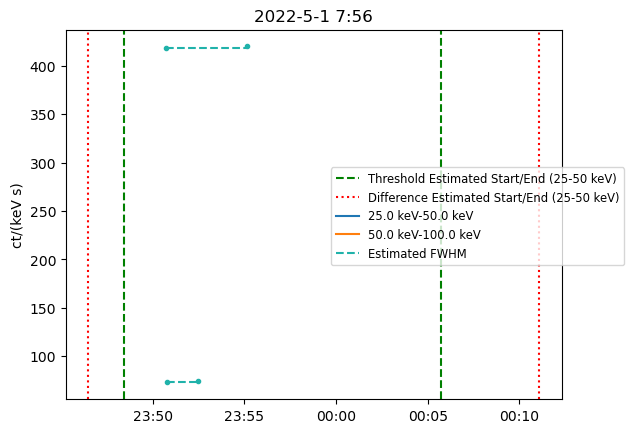

In [159]:
i=0

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
sci_df = df_list_filtered[np.where(indices_array==ind)[0][0]]

r = top100['solo_position_AU_distance'].loc[ind]

tstart = filtered_stats_df['start_time'].iloc[i]
tend = filtered_stats_df['end_time'].iloc[i]

tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

plt.axvline(t(tend), 0, 1, color = 'green', linestyle = 'dashed', label = 'Threshold Estimated Start/End (25-50 keV)')
plt.axvline(t(tstart), 0, 1, color = 'green', linestyle = 'dashed')
plt.axvline(estimated_starts[i], 0, 1, linestyle = 'dotted', color='red', label = 'Difference Estimated Start/End (25-50 keV)')
plt.axvline(estimated_ends[i], 0, 1, linestyle = 'dotted', color='red')

plot_df = sci_df.truncate(t(tstart)-dt.timedelta(minutes=20), t(tend)+dt.timedelta(minutes=20))
for n in range(len(plot_df.columns)):
    ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

# ax.plot(t(half_max_points[i]), half_max_vals[i], marker='o',ms=3, color='lightseagreen')
# ax.hlines(half_max_vals[i], t(half_max_points[i]), t(half_max_points[i]) + fwhm_list[i], linestyle='dashed', color='lightseagreen', label = 'Estimated FWHM')
# ax.plot(t(end_points[i]), end_point_vals[i], marker='o', ms=3, color='lightseagreen')


if pd.notna(fwhm_list_50100[i]):
    ax.plot(t(half_max_points_50100[i]), half_max_vals_50100[i], marker='o', ms=3, color='lightseagreen')
    ax.hlines(half_max_vals_50100[i], t(half_max_points_50100[i]), t(half_max_points_50100[i]) + fwhm_list_50100[i], linestyle='dashed', color='lightseagreen')
    ax.plot(t(end_points_50100[i]), end_point_vals_50100[i], marker='o', ms=3, color='lightseagreen')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', fontsize='small')
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_4/fwhm_testing/duration_comparisons/flare"+str(i)+".png", bbox_inches='tight')


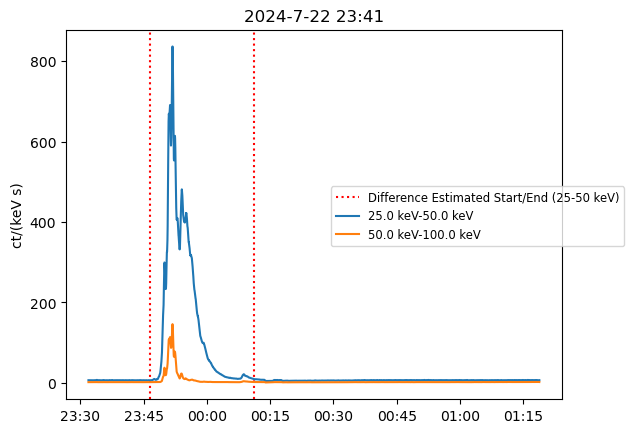

In [26]:
i=0

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
ax.set_title(f"{parse_time(top100['start_UTC'].iloc[i]).datetime.year}-{parse_time(top100['start_UTC'].iloc[i]).datetime.month}-{parse_time(top100['start_UTC'].iloc[i]).datetime.day} {parse_time(top100['start_UTC'].iloc[i]).datetime.hour}:{parse_time(top100['start_UTC'].iloc[i]).datetime.minute}")
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
sci_df = df_list_filtered[i]

r = top100['solo_position_AU_distance'].iloc[i]

tstart = filtered_stats_df['start_time'].iloc[i]
tend = filtered_stats_df['end_time'].iloc[i]

tstart_50_100 = filtered_stats_df['start_time (50-100 keV)'].iloc[i]
tend_50_100 = filtered_stats_df['end_time (50-100 keV)'].iloc[i]

# plt.axvline(t(tend), 0, 1, color = 'limegreen', linestyle = 'dashed', label = 'Threshold Estimated Start/End (25-50 keV)')
# plt.axvline(t(tstart), 0, 1, color = 'limegreen', linestyle = 'dashed')

plt.axvline(estimated_starts[i], 0, 1, linestyle = 'dotted', color='red', label = 'Difference Estimated Start/End (25-50 keV)')
plt.axvline(estimated_ends[i], 0, 1, linestyle = 'dotted', color='red')

# plt.axvline(t(top100['start_UTC'].iloc[i]), 0, 1, color = 'yellow', linestyle = 'dashed', label = 'Flare List Start/End (25-50 keV)')
# plt.axvline(t(top100['end_UTC'].iloc[i]), 0, 1, color = 'yellow', linestyle = 'dashed')

plot_df = sci_df.truncate(t(top100['start_UTC'].iloc[i])-dt.timedelta(minutes=10), t(top100['end_UTC'].iloc[i])+dt.timedelta(minutes=10))
for n in range(len(plot_df.columns)):
    ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

# ax.plot(t(half_max_points[i]), half_max_vals[i], marker='o',ms=3, color='lightseagreen')
# ax.hlines(half_max_vals[i], t(half_max_points[i]), t(half_max_points[i]) + fwhm_list[i], linestyle='dashed', color='lightseagreen', label = 'Estimated FWHM')
# ax.plot(t(end_points[i]), end_point_vals[i], marker='o', ms=3, color='lightseagreen')


# if pd.notna(fwhm_list_50100[i]):
#     ax.plot(t(half_max_points_50100[i]), half_max_vals_50100[i], marker='o', ms=3, color='lightseagreen')
#     ax.hlines(half_max_vals_50100[i], t(half_max_points_50100[i]), t(half_max_points_50100[i]) + fwhm_list_50100[i], linestyle='dashed', color='lightseagreen')
#     ax.plot(t(end_points_50100[i]), end_point_vals_50100[i], marker='o', ms=3, color='lightseagreen')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', fontsize='small')
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_8/figs_for_presentation/flare"+str(i)+"_difference.png", bbox_inches='tight')


C:\Users\derva\AppData\Local\Temp\ipykernel_15520\336957123.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


IndexError: index 0 is out of bounds for axis 0 with size 0

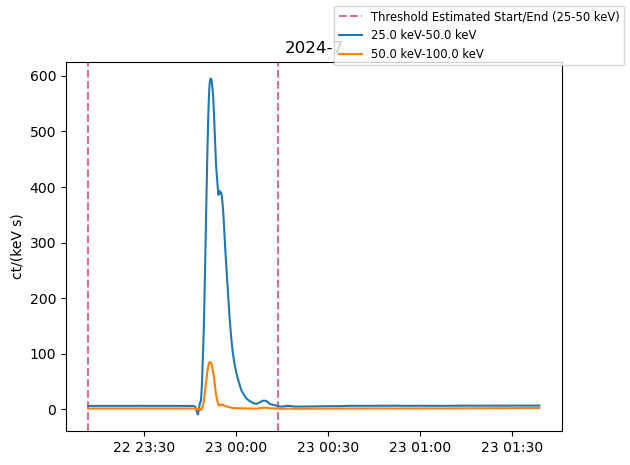

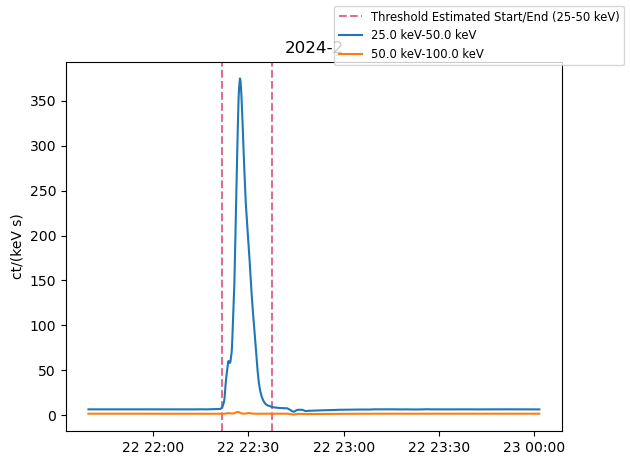

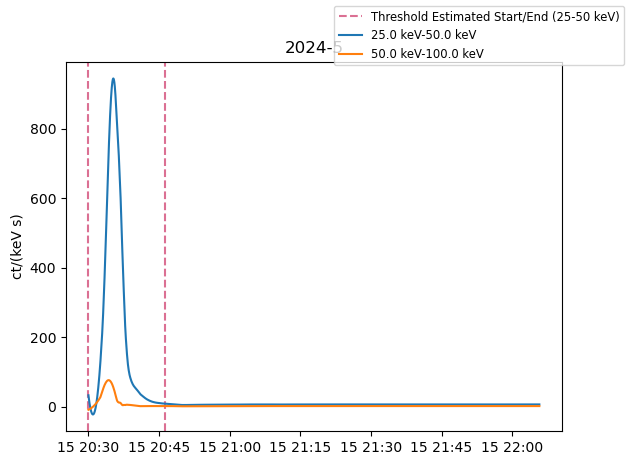

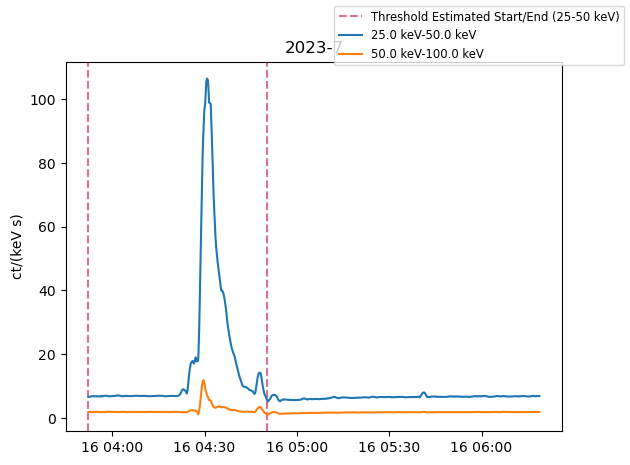

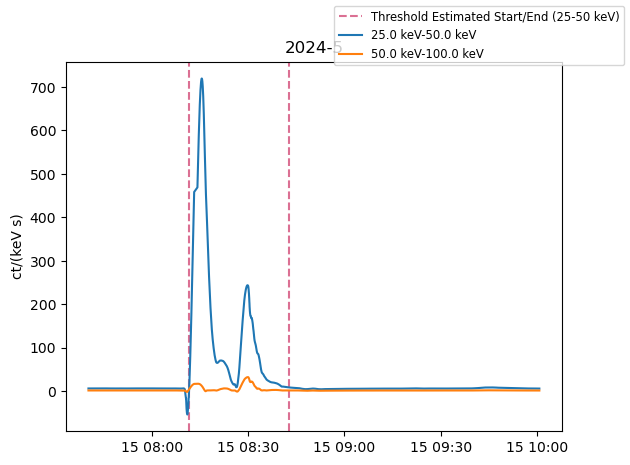

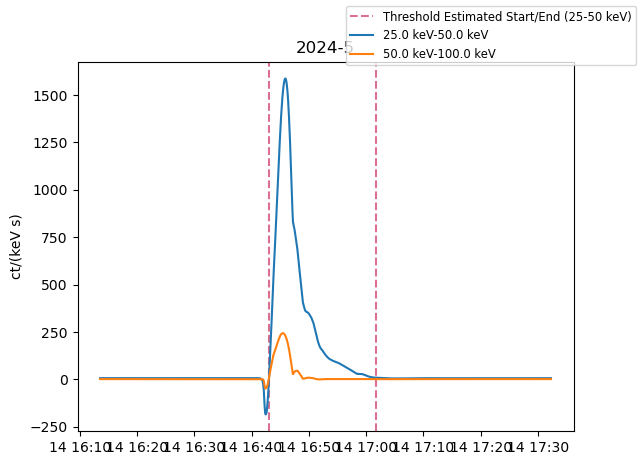

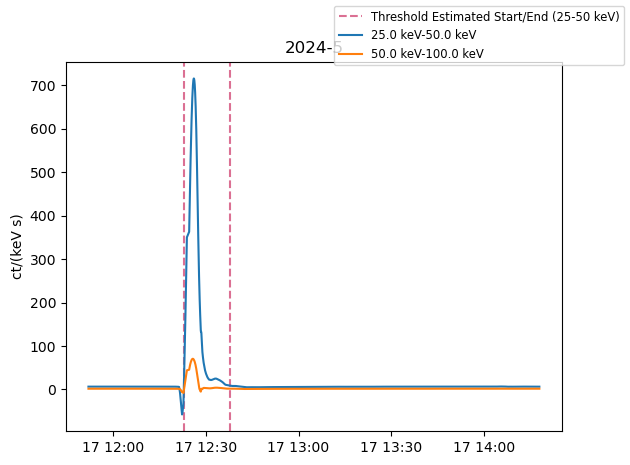

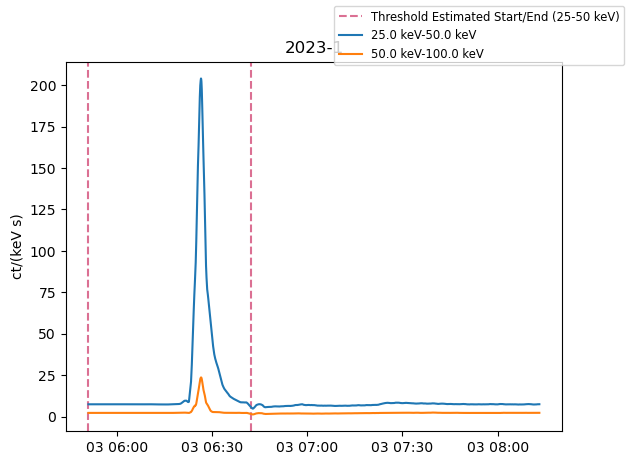

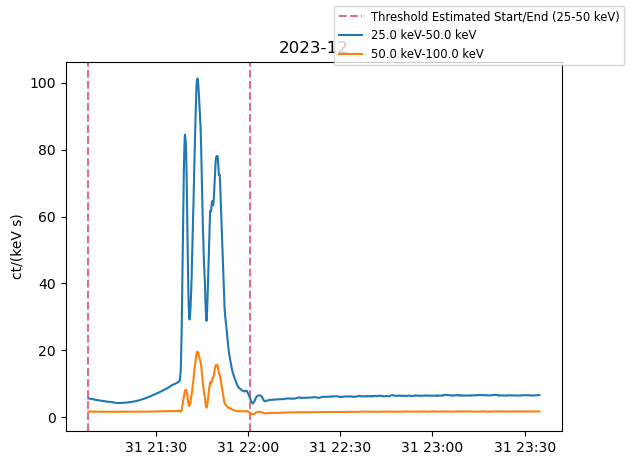

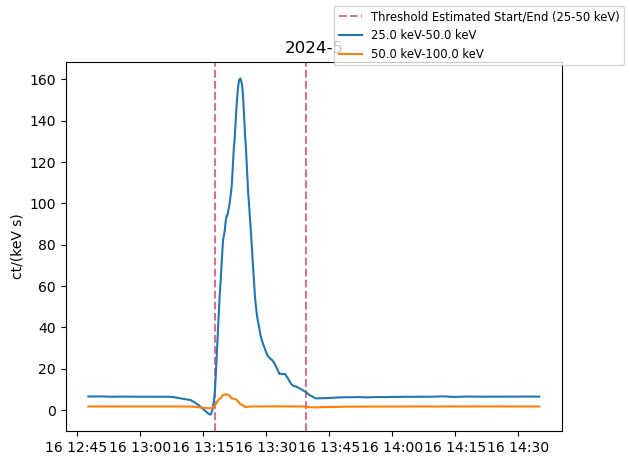

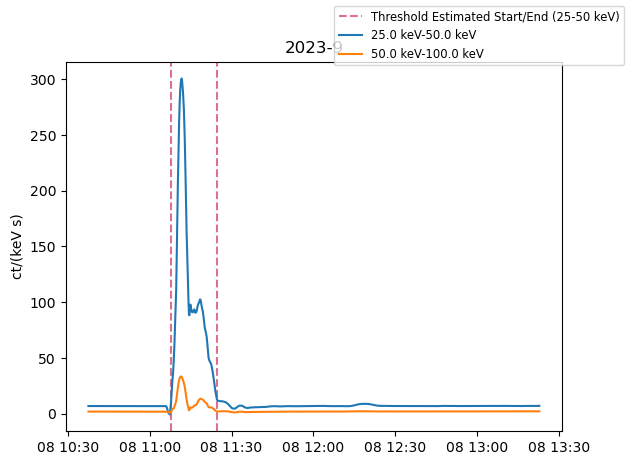

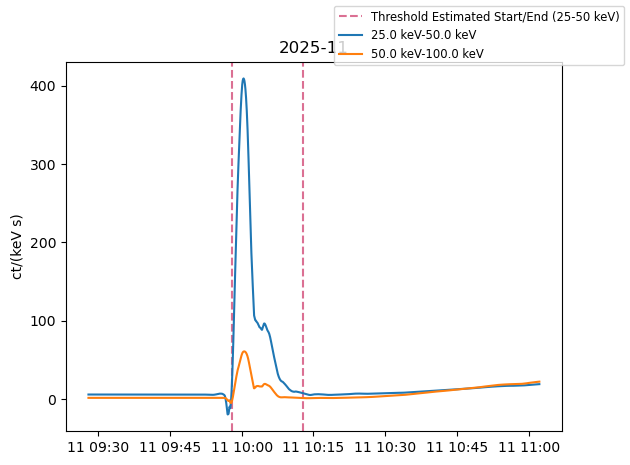

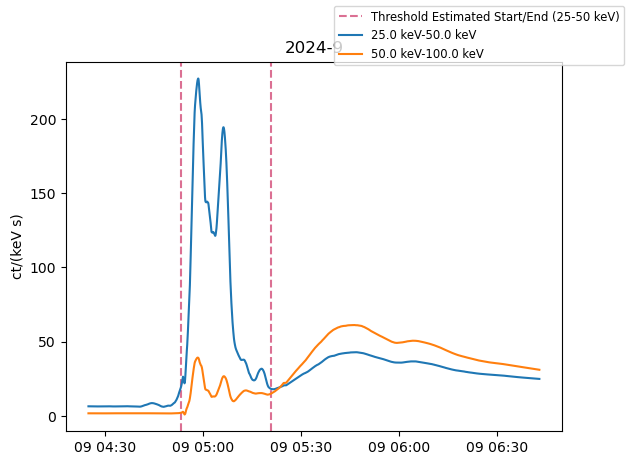

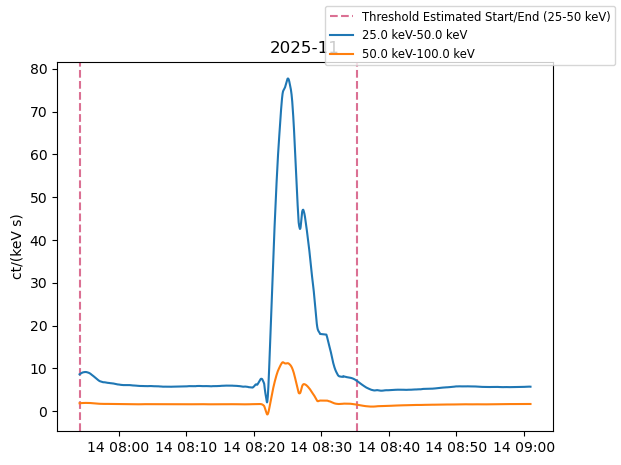

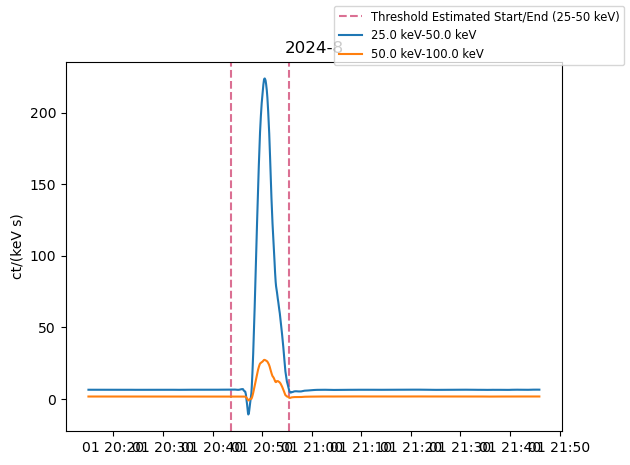

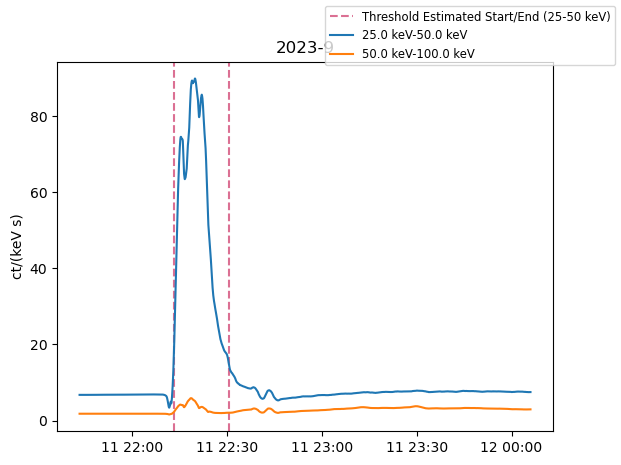

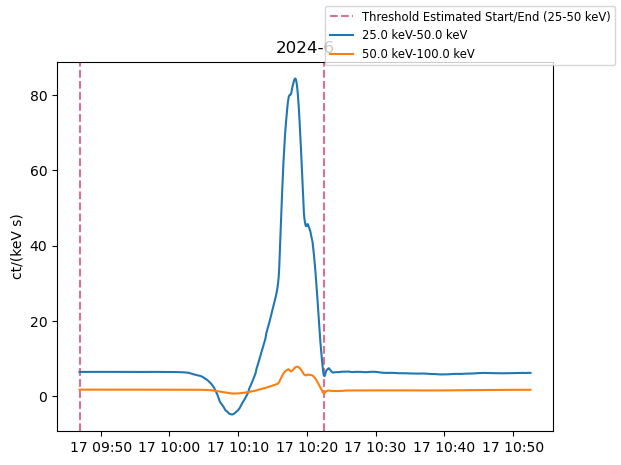

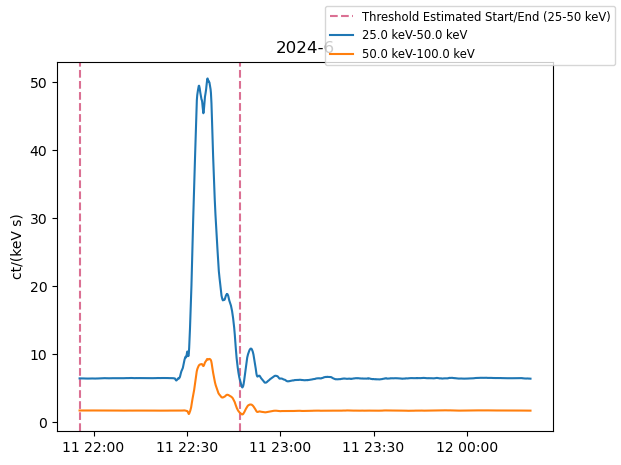

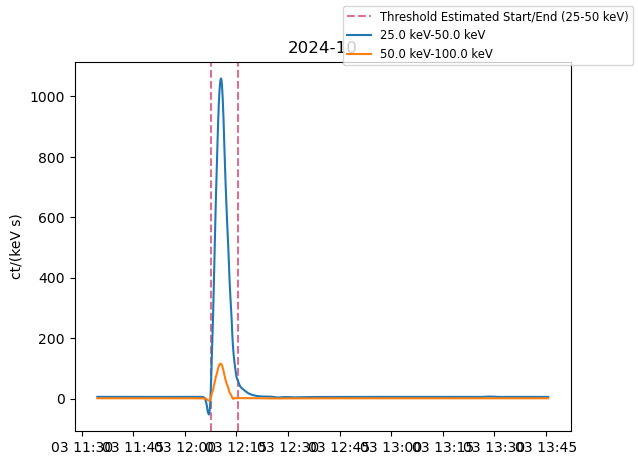

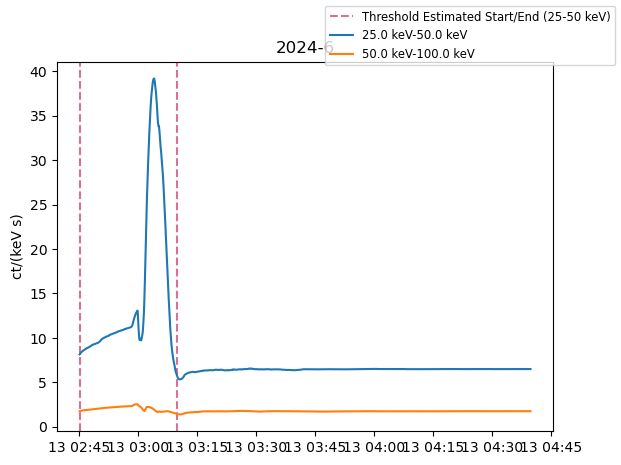

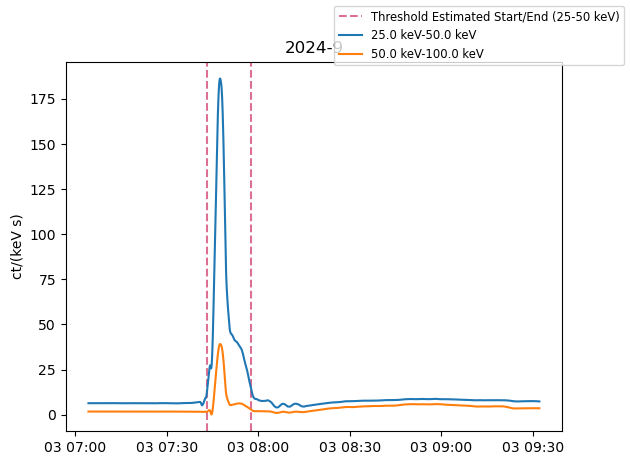

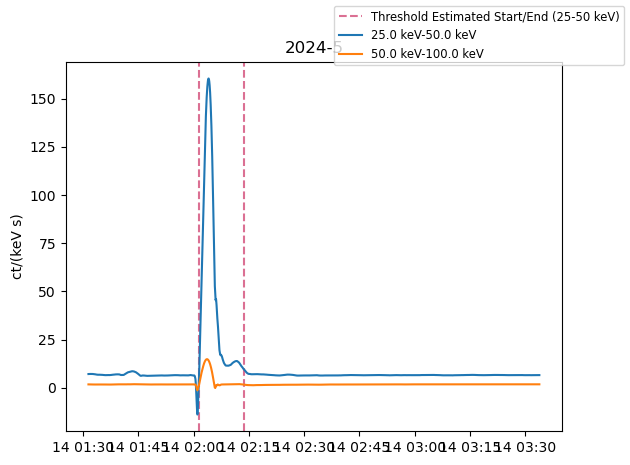

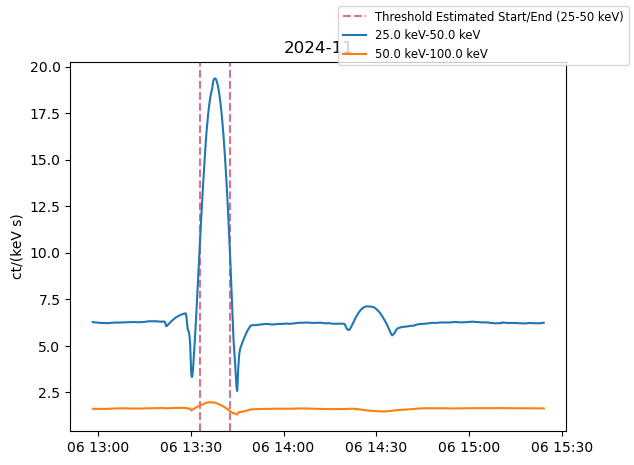

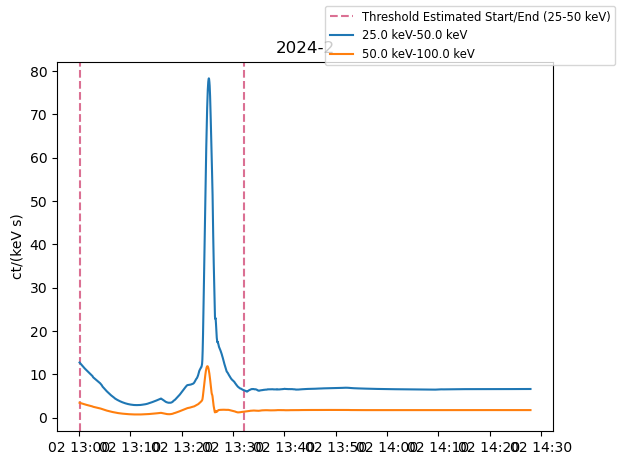

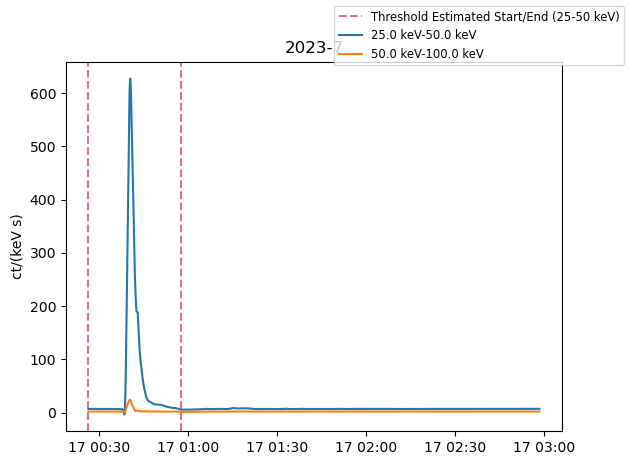

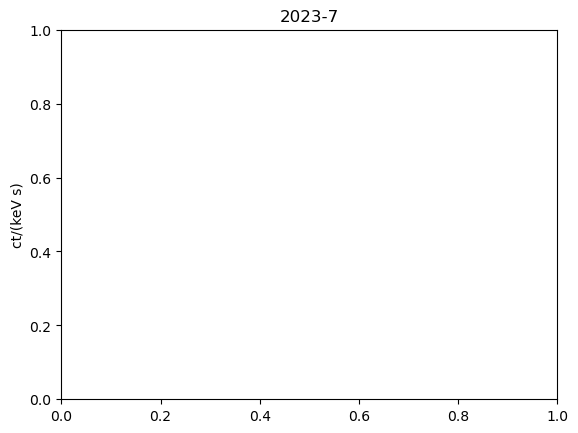

In [76]:
i=0
peak_locs = [[] for _ in range(len(indices_refined))]
for ind in indices:
    if ind in indices_refined:
        if i not in bad_diff:
            fig, ax = plt.subplots()
            ax.set_ylabel('ct/(keV s)')
            ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
            sci_df = df_list_extrafiltered[np.where(indices_array==ind)[0][0]]
    
            r = top100['solo_position_AU_distance'].loc[ind]
            
            start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
            end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
        
            plot_df = sci_df.truncate(start, end)

            peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
            peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
            
            flare = plot_df[plot_df['25.0 keV-50.0 keV']>5/r**2]
            tstart = flare.index[0]
            tend = plot_df[(plot_df['25.0 keV-50.0 keV']<5/r**2) & (plot_df.index>peak_loc)].index[0]
    
            plt.axvline(t(tend), 0, 1, color = 'palevioletred', linestyle = 'dashed', label = 'Threshold Estimated Start/End (25-50 keV)')
            plt.axvline(t(tstart), 0, 1, color = 'palevioletred', linestyle = 'dashed')
            
            for n in range(len(plot_df.columns)):
                ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
            
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels, loc='upper right', fontsize='small')
            fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/threshold_testing/flare"+str(i)+".png", bbox_inches='tight')

        i+=1
    
plt.close('all')

In [77]:
filtered_stats_df.columns

Index(['flare_list_id', 'start_time', 'end_time', 'peak_time', 'peak_counts',
       'number_of_peaks', 'rise_time', 'decay_time', 'start_time (50-100 keV)',
       'end_time (50-100 keV)', 'peak_counts (50-100 keV)',
       'rise_time (50-100 keV)', 'decay_time (50-100 keV)', 'FWHM (25-50 keV)',
       'FWHM (50-100 keV)', 'comments'],
      dtype='str')

In [78]:
i=0
for ind in top100.index:
    #ax=axes[i]
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}-{parse_time(top100['start_UTC'].loc[ind]).datetime.day} {parse_time(top100['start_UTC'].loc[ind]).datetime.hour}:{parse_time(top100['start_UTC'].loc[ind]).datetime.minute}")
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
    start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
    end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

    plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
    plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
    plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
    plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

    plt.axhline(10, 0, 1, color='red', linestyle='dotted')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_15520\4186899231.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [79]:
len(filtered_stats_df['peak_counts'])

83

In [80]:
peak_counts_diff = []
for i in range(len(filtered_stats_df['peak_counts'])):
    if i not in bad_diff:
        peak_counts_diff.append(filtered_stats_df['peak_counts'].iloc[i])
    else:
        peak_counts_diff.append(np.nan)

peak_counts_diff_50_100 = []
for i in range(len(filtered_stats_df['peak_counts (50-100 keV)'])):
    if i not in bad_diff:
        peak_counts_diff_50_100.append(filtered_stats_df['peak_counts (50-100 keV)'].iloc[i])
    else:
        peak_counts_diff_50_100.append(np.nan)

In [81]:
peak_counts_diff_corr = []
durations_diff_corr = []
for i in range(len(durations_diff)):
    if pd.notna(durations_diff[i]):
        durations_diff_corr.append(durations_diff[i])
        peak_counts_diff_corr.append(peak_counts_diff[i])

In [82]:
spearmanr(peak_counts_diff_corr, durations_diff_corr)

SignificanceResult(statistic=np.float64(0.2961619093694565), pvalue=np.float64(0.031299710390586426))

In [83]:
pearsonr(peak_counts_diff_corr, durations_diff_corr)

PearsonRResult(statistic=np.float64(0.029984781211737168), pvalue=np.float64(0.8312215678407827))

In [84]:
pearsonr(np.log10(peak_counts_diff_corr), np.log10(durations_diff_corr))

PearsonRResult(statistic=np.float64(0.27185821694243995), pvalue=np.float64(0.04892715273842814))

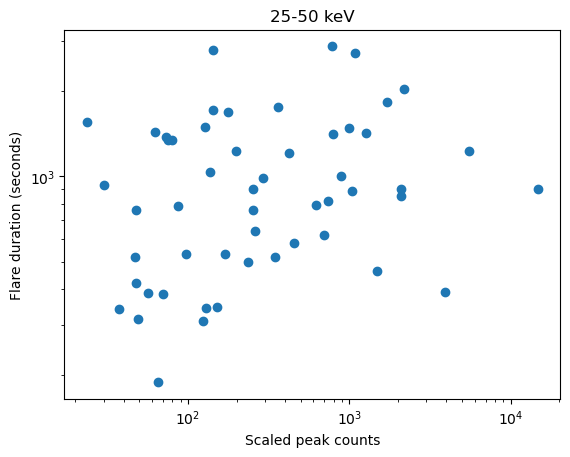

In [85]:
plt.scatter(peak_counts_diff, durations_diff)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.xlabel('Scaled peak counts')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/difference_duration_vs_peak_counts.png", bbox_inches='tight')

In [86]:
peak_counts_diff_50100_corr = []
durations_diff_50100_corr = []
for i in range(len(durations_diff_50100)):
    if pd.notna(durations_diff_50100[i]):
        durations_diff_50100_corr.append(durations_diff_50100[i])
        peak_counts_diff_50100_corr.append(peak_counts_diff_50_100[i])

In [87]:
spearmanr(peak_counts_diff_50100_corr, durations_diff_50100_corr)

SignificanceResult(statistic=np.float64(0.36423304432379877), pvalue=np.float64(0.017722634282964667))

In [88]:
pearsonr(peak_counts_diff_50100_corr, durations_diff_50100_corr)

PearsonRResult(statistic=np.float64(-0.08804956096803188), pvalue=np.float64(0.5792473303296999))

In [89]:
pearsonr(np.log10(peak_counts_diff_50100_corr), np.log10(durations_diff_50100_corr))

PearsonRResult(statistic=np.float64(0.30509051289123085), pvalue=np.float64(0.04945306545749586))

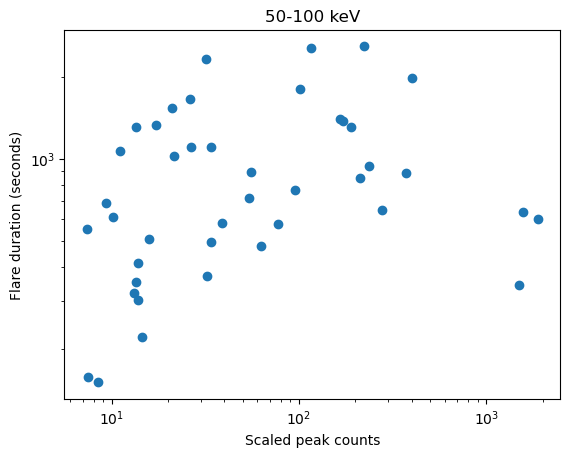

In [90]:
plt.scatter(peak_counts_diff_50_100, durations_diff_50100)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.xlabel('Scaled peak counts')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/difference_duration_vs_peak_counts_50_100.png", bbox_inches='tight')

In [91]:
spearmanr(filtered_stats_df['peak_counts'], filtered_stats_df['FWHM (25-50 keV)'])

SignificanceResult(statistic=np.float64(-0.03397408655040981), pvalue=np.float64(0.7604326890991709))

In [92]:
pearsonr(filtered_stats_df['peak_counts'], filtered_stats_df['FWHM (25-50 keV)'])

PearsonRResult(statistic=np.float64(-0.08902721252701362), pvalue=np.float64(0.42349817601536005))

In [93]:
pearsonr(np.log10(filtered_stats_df['peak_counts']), np.log10(filtered_stats_df['FWHM (25-50 keV)']))

PearsonRResult(statistic=np.float64(-0.06845090190676795), pvalue=np.float64(0.5386328643186028))

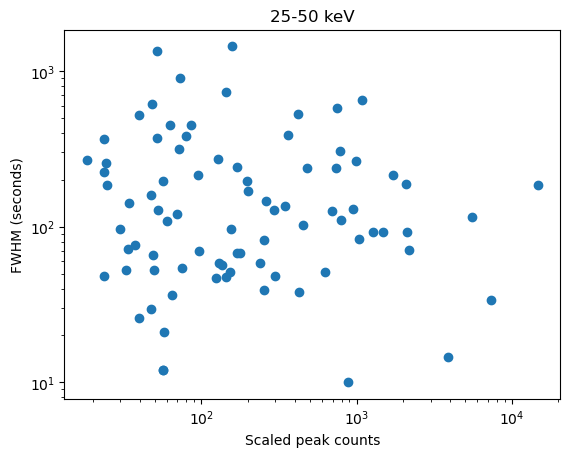

In [94]:
plt.scatter(filtered_stats_df['peak_counts'], filtered_stats_df['FWHM (25-50 keV)'])
plt.yscale('log')
plt.xscale('log')
plt.ylabel('FWHM (seconds)')
plt.xlabel('Scaled peak counts')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/fwhm_vs_peak_counts.png", bbox_inches='tight')

In [95]:
fwhm_50100_corr = []
for i in range(len(filtered_stats_df['FWHM (50-100 keV)'])):
    if pd.notna(filtered_stats_df['FWHM (50-100 keV)'].loc[i]):
        fwhm_50100_corr.append(filtered_stats_df['FWHM (50-100 keV)'].loc[i])

In [96]:
spearmanr(peak_counts_50_100_corr, fwhm_50100_corr)

SignificanceResult(statistic=np.float64(-0.21433293853891794), pvalue=np.float64(0.09717616817870812))

In [97]:
pearsonr(peak_counts_50_100_corr, fwhm_50100_corr)

PearsonRResult(statistic=np.float64(-0.13999887613972142), pvalue=np.float64(0.28187540403851724))

In [98]:
spearmanr(np.log10(peak_counts_50_100_corr), np.log10(fwhm_50100_corr))

SignificanceResult(statistic=np.float64(-0.21433293853891794), pvalue=np.float64(0.09717616817870812))

In [99]:
pearsonr(np.log10(peak_counts_50_100_corr), np.log10(fwhm_50100_corr))

PearsonRResult(statistic=np.float64(-0.2384050626434565), pvalue=np.float64(0.06427611398253942))

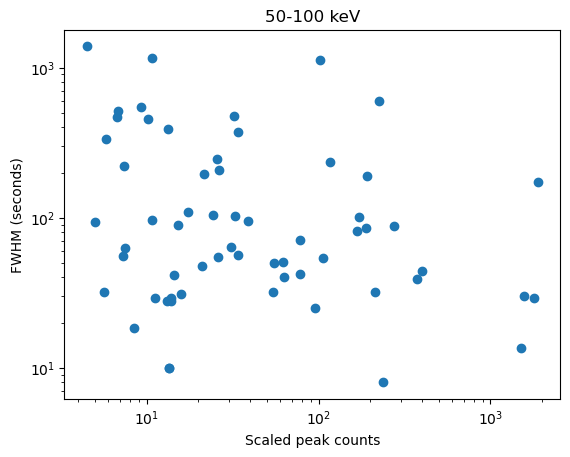

In [100]:
plt.scatter(filtered_stats_df['peak_counts (50-100 keV)'], filtered_stats_df['FWHM (50-100 keV)'])
plt.yscale('log')
plt.xscale('log')
plt.ylabel('FWHM (seconds)')
plt.xlabel('Scaled peak counts')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/fwhm_vs_peak_counts_50_100.png", bbox_inches='tight')

In [101]:
spearmanr(filtered_stats_df['peak_counts'], peak_ratios)

SignificanceResult(statistic=np.float64(0.2744637084925066), pvalue=np.float64(0.012039562165504438))

In [102]:
pearsonr(filtered_stats_df['peak_counts'], peak_ratios)

PearsonRResult(statistic=np.float64(0.22950009074361516), pvalue=np.float64(0.03688081831211061))

In [103]:
spearmanr(np.log10(filtered_stats_df['peak_counts']), peak_ratios)

SignificanceResult(statistic=np.float64(0.2744637084925066), pvalue=np.float64(0.012039562165504438))

In [104]:
pearsonr(np.log10(filtered_stats_df['peak_counts']), peak_ratios)

PearsonRResult(statistic=np.float64(0.3164738797956621), pvalue=np.float64(0.0035591274208640134))

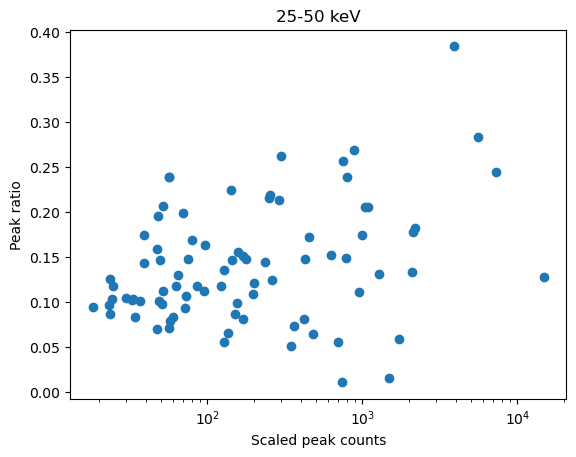

In [105]:
plt.scatter(filtered_stats_df['peak_counts'], peak_ratios)
#plt.yscale('log')
plt.xscale('log')
plt.ylabel('Peak ratio')
plt.xlabel('Scaled peak counts')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/peak_ratio_vs_peak_counts.png", bbox_inches='tight')

In [106]:
spearmanr(filtered_stats_df['peak_counts (50-100 keV)'], peak_ratios)

SignificanceResult(statistic=np.float64(0.5356618110070945), pvalue=np.float64(1.8074326268838973e-07))

In [107]:
pearsonr(filtered_stats_df['peak_counts (50-100 keV)'], peak_ratios)

PearsonRResult(statistic=np.float64(0.4553641032212673), pvalue=np.float64(1.5223544855905896e-05))

In [108]:
pearsonr(np.log10(filtered_stats_df['peak_counts (50-100 keV)']), peak_ratios)

PearsonRResult(statistic=np.float64(0.5832721470078797), pvalue=np.float64(7.192625217759739e-09))

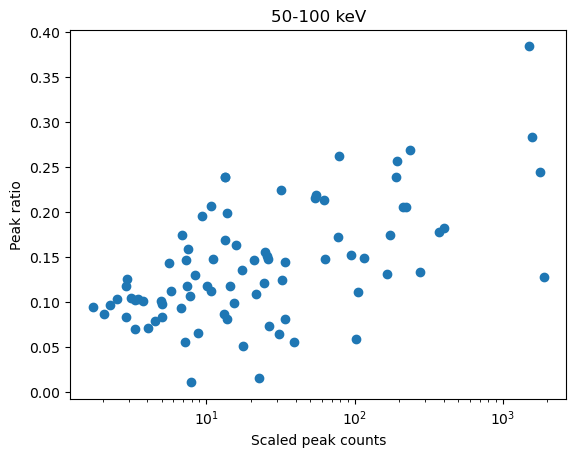

In [109]:
plt.scatter(filtered_stats_df['peak_counts (50-100 keV)'], peak_ratios)
#plt.yscale('log')
plt.xscale('log')
plt.ylabel('Peak ratio')
plt.xlabel('Scaled peak counts')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/peak_ratio_vs_peak_counts_50_100.png", bbox_inches='tight')

In [110]:
durations_diff_corr_2 = []
for i in range(len(durations_diff_50100)):
    if pd.notna(durations_diff_50100[i]):
        durations_diff_corr_2.append(durations_diff[i])

In [111]:
spearmanr(durations_diff_50100_corr, durations_diff_corr_2)

SignificanceResult(statistic=np.float64(0.9191313507819465), pvalue=np.float64(8.925568027089594e-18))

In [112]:
pearsonr(durations_diff_50100_corr, durations_diff_corr_2)

PearsonRResult(statistic=np.float64(0.9543994206649045), pvalue=np.float64(1.3095839626267232e-22))

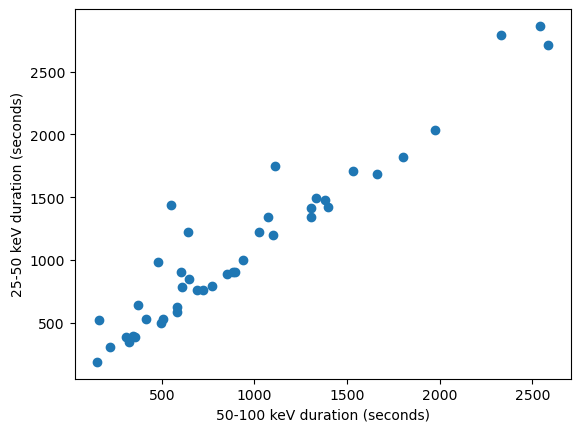

In [113]:
plt.scatter(durations_diff_50100, durations_diff)
plt.xlabel('50-100 keV duration (seconds)')
plt.ylabel('25-50 keV duration (seconds)')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/durations.png", bbox_inches='tight')

In [114]:
peak_ratios_corr = []
for i in range(len(durations_diff)):
    if pd.notna(durations_diff[i]):
        peak_ratios_corr.append(peak_ratios[i])

In [115]:
spearmanr(peak_ratios_corr, durations_diff_corr)

SignificanceResult(statistic=np.float64(0.18843734881470728), pvalue=np.float64(0.17660771953107252))

In [116]:
pearsonr(peak_ratios_corr, durations_diff_corr)

PearsonRResult(statistic=np.float64(0.134175856929427), pvalue=np.float64(0.3381317847056744))

In [117]:
pearsonr(peak_ratios_corr, np.log10(durations_diff_corr))

PearsonRResult(statistic=np.float64(0.1259455119440388), pvalue=np.float64(0.3688556242461468))

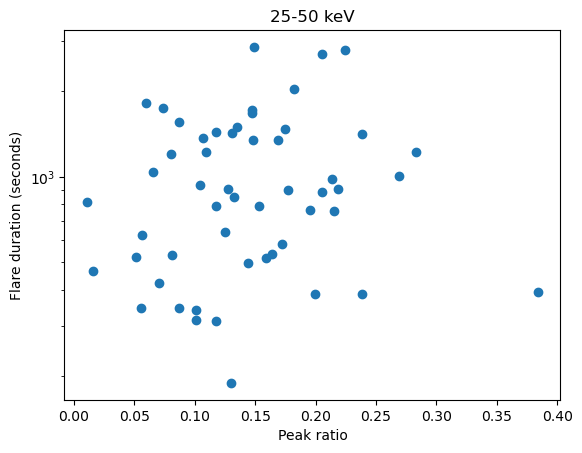

In [118]:
plt.scatter(peak_ratios, durations_diff)
plt.yscale('log')
# plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('25-50 keV')
plt.xlabel('Peak ratio')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/difference_duration_vs_peak_ratio.png", bbox_inches='tight')

In [119]:
peak_ratios_50100_corr_2 = []
for i in range(len(durations_diff_50100)):
    if pd.notna(durations_diff_50100[i]):
        peak_ratios_50100_corr_2.append(peak_ratios[i])

In [120]:
spearmanr(peak_ratios_50100_corr_2, durations_diff_50100_corr)

SignificanceResult(statistic=np.float64(0.08208410987764364), pvalue=np.float64(0.6053060123186351))

In [121]:
pearsonr(peak_ratios_50100_corr_2, durations_diff_50100_corr)

PearsonRResult(statistic=np.float64(0.0025339629828621812), pvalue=np.float64(0.9872931294798262))

In [122]:
pearsonr(peak_ratios_50100_corr_2, np.log10(durations_diff_50100_corr))

PearsonRResult(statistic=np.float64(-0.0036996839434182), pvalue=np.float64(0.9814483314388031))

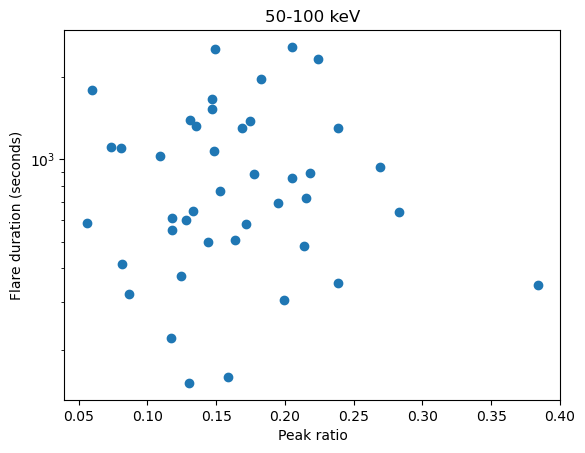

In [123]:
plt.scatter(peak_ratios, durations_diff_50100)
plt.yscale('log')
# plt.xscale('log')
plt.ylabel('Flare duration (seconds)')
plt.title('50-100 keV')
plt.xlabel('Peak ratio')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/difference_duration_vs_peak_ratio_50_100.png", bbox_inches='tight')

In [124]:
spearmanr(peak_ratios, filtered_stats_df['FWHM (25-50 keV)'])

SignificanceResult(statistic=np.float64(-0.14377850221009084), pvalue=np.float64(0.19471083533356792))

In [125]:
pearsonr(peak_ratios, filtered_stats_df['FWHM (25-50 keV)'])

PearsonRResult(statistic=np.float64(0.04587478471411835), pvalue=np.float64(0.6804729851333602))

In [126]:
pearsonr(peak_ratios, np.log10(filtered_stats_df['FWHM (25-50 keV)']))

PearsonRResult(statistic=np.float64(-0.21475905006807408), pvalue=np.float64(0.05121313177724656))

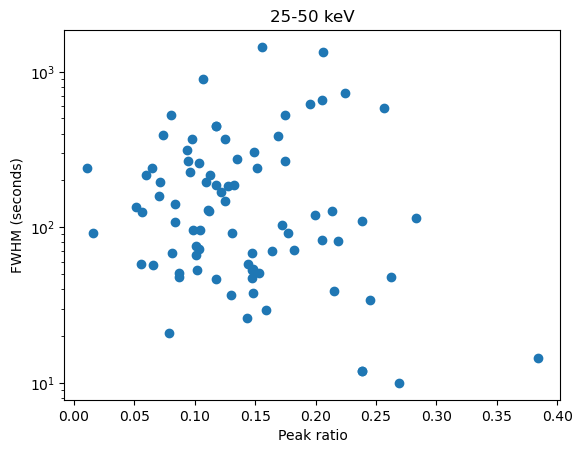

In [127]:
plt.scatter(peak_ratios, filtered_stats_df['FWHM (25-50 keV)'])
plt.yscale('log')
plt.ylabel('FWHM (seconds)')
plt.xlabel('Peak ratio')
plt.title('25-50 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/fwhm_vs_peak_ratio.png", bbox_inches='tight')

In [128]:
spearmanr(peak_ratios_50100_corr, fwhm_50100_corr)

SignificanceResult(statistic=np.float64(-0.34687293705305194), pvalue=np.float64(0.006168040312186326))

In [129]:
pearsonr(peak_ratios_50100_corr, fwhm_50100_corr)

PearsonRResult(statistic=np.float64(-0.2072487717351471), pvalue=np.float64(0.10901596969838245))

In [130]:
pearsonr(peak_ratios_50100_corr, np.log10(fwhm_50100_corr))

PearsonRResult(statistic=np.float64(-0.3749939430938902), pvalue=np.float64(0.0029042920597276917))

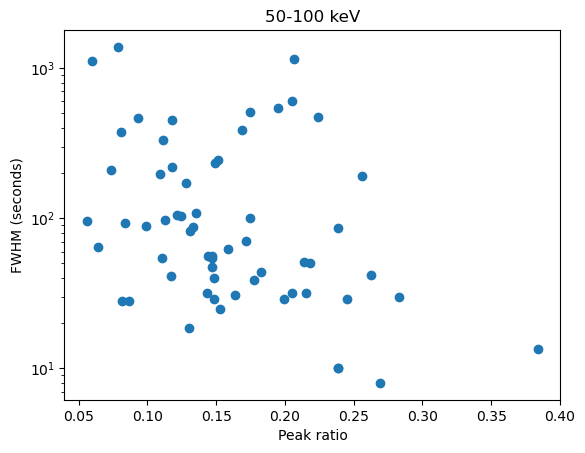

In [131]:
plt.scatter(peak_ratios, filtered_stats_df['FWHM (50-100 keV)'])
plt.yscale('log')
plt.ylabel('FWHM (seconds)')
plt.xlabel('Peak ratio')
plt.title('50-100 keV')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_6/statistics_plots/fwhm_vs_peak_ratio_50_100.png", bbox_inches='tight')

In [132]:
filtered_stats_df.sort_values("peak_counts", ascending=False)

,flare_list_id,start_time,end_time,peak_time,peak_counts,number_of_peaks,rise_time,decay_time,start_time (50-100 keV),end_time (50-100 keV),peak_counts (50-100 keV),rise_time (50-100 keV),decay_time (50-100 keV),FWHM (25-50 keV),FWHM (50-100 keV),comments
21,21278,2024-10-03 12:08:20.275000,2024-10-03 12:14:28.275000,2024-10-03 12:09:47.275000,14774.197986,3.0,00:01:27,00:04:41,2024-10-03 12:08:43.275000,2024-10-03 12:12:05.275000,1887.025259,00:01:04,00:02:18,185.0,173.0,0.0
1,16121,2024-05-20 05:12:01.632000,2024-05-20 05:21:12.632000,2024-05-20 05:13:11.632000,7324.687190,1.0,00:01:10,00:08:01,2024-05-20 05:12:07.632000,2024-05-20 05:19:30.632000,1793.520212,00:01:05,00:06:18,34.0,29.0,0.0
6,15798,2024-05-14 16:43:56.071000,2024-05-14 16:59:59.071000,2024-05-14 16:44:48.071000,5554.918625,2.0,00:00:52,00:15:11,2024-05-14 16:44:11.071000,2024-05-14 16:49:53.071000,1573.475811,00:00:37,00:05:05,115.0,30.0,0.0
34,2060,2022-04-20 03:50:47.419000,2022-04-20 03:53:41.919000,2022-04-20 03:51:14.419000,3904.495923,1.0,00:00:27,00:02:27.500000,2022-04-20 03:50:53.419000,2022-04-20 03:52:01.419000,1499.485484,00:00:21,00:00:47,14.5,13.5,0.0
65,17859,2024-07-27 04:29:13.488000,2024-07-27 04:55:31.488000,2024-07-27 04:31:42.488000,2190.710157,1.0,00:02:29,00:23:49,2024-07-27 04:29:54.488000,2024-07-27 04:55:31.488000,399.335210,00:01:48,00:23:49,71.0,44.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,24906,2025-02-03 03:52:26.654000,2025-02-03 03:52:59.654000,2025-02-03 03:52:41.654000,24.308365,1.0,00:00:15,00:00:18,NaN,NaN,2.513646,NaN,NaN,258.0,NaN,0.0
77,24215,2024-12-30 16:53:31.282000,2024-12-30 16:54:22.282000,2024-12-30 16:53:55.282000,23.658582,1.0,00:00:24,00:00:27,NaN,NaN,2.056632,NaN,NaN,48.0,NaN,0.0
63,16662,2024-06-10 18:20:45.109000,2024-06-10 18:23:04.109000,2024-06-10 18:21:21.109000,23.440495,2.0,00:00:36,00:01:43,NaN,NaN,2.934882,NaN,NaN,368.0,NaN,0.0
67,16837,2024-06-16 15:34:37.250000,2024-06-16 15:38:03.250000,2024-06-16 15:37:29.250000,23.415029,2.0,00:02:52,00:00:34,NaN,NaN,2.254177,NaN,NaN,226.0,NaN,0.0
